In [1]:
!nvidia-smi

Thu Sep  3 09:30:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.7 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.138


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
!ls -lah "/content/drive/MyDrive/football-adboard-segmentation/datasets"

total 12K
drwx------ 2 root root 4.0K Aug 21 17:27 reviewed_test_100
drwx------ 2 root root 4.0K Aug 19 17:33 rf_detr
drwx------ 2 root root 4.0K Aug 22 12:36 segmentation


In [10]:
from pathlib import Path

DRIVE_ZIP = Path(
    "/content/drive/MyDrive/football-adboard-segmentation/datasets/yolo.zip"
)

WORK_DIR = Path("/content/yolo_project")

assert DRIVE_ZIP.exists(), f"ZIP non trovato: {DRIVE_ZIP}"

print("ZIP trovato:")
print(DRIVE_ZIP)

ZIP trovato:
/content/drive/MyDrive/football-adboard-segmentation/datasets/yolo.zip


In [11]:
import zipfile
import shutil

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

WORK_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DRIVE_ZIP, "r") as zip_ref:
    zip_ref.extractall(WORK_DIR)

print("Estrazione completata.")

Estrazione completata.


In [12]:
!find /content/yolo_project -maxdepth 3 -type d | sort

/content/yolo_project
/content/yolo_project/yolo
/content/yolo_project/yolo/images
/content/yolo_project/yolo/images/test
/content/yolo_project/yolo/images/train
/content/yolo_project/yolo/images/valid
/content/yolo_project/yolo/labels
/content/yolo_project/yolo/labels/test
/content/yolo_project/yolo/labels/train
/content/yolo_project/yolo/labels/valid


In [16]:
from pathlib import Path

DATASET_DIR = Path("/content/yolo_project/yolo")

print(DATASET_DIR)
print("Esiste:", DATASET_DIR.exists())

/content/yolo_project/yolo
Esiste: True


In [17]:
def count_images(directory: Path) -> int:
    extensions = {".jpg", ".jpeg", ".png"}

    return sum(
        1
        for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in extensions
    )


def count_boxes(directory: Path) -> int:
    total = 0

    for label_path in directory.glob("*.txt"):
        with label_path.open("r", encoding="utf-8") as file:
            total += sum(
                1
                for line in file
                if line.strip()
            )

    return total


expected = {
    "train": (6196, 13349),
    "valid": (1328, 2858),
    "test": (1327, 2939),
}


for split, (expected_images, expected_boxes) in expected.items():

    n_images = count_images(
        DATASET_DIR / "images" / split
    )

    n_boxes = count_boxes(
        DATASET_DIR / "labels" / split
    )

    print(
        f"{split:5s} | "
        f"images = {n_images:4d} | "
        f"boxes = {n_boxes:5d}"
    )

    assert n_images == expected_images
    assert n_boxes == expected_boxes

print("\nDataset verificato correttamente.")

train | images = 6196 | boxes = 13349
valid | images = 1328 | boxes =  2858
test  | images = 1327 | boxes =  2939

Dataset verificato correttamente.


In [18]:
import yaml

DATASET_YAML = DATASET_DIR / "dataset_colab.yaml"

config = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/valid",
    "test": "images/test",
    "names": {
        0: "advertising_board",
    },
}

with DATASET_YAML.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        config,
        file,
        sort_keys=False,
    )

print(DATASET_YAML.read_text())

path: /content/yolo_project/yolo
train: images/train
val: images/valid
test: images/test
names:
  0: advertising_board



In [19]:
import random

labels = list(
    (DATASET_DIR / "labels" / "train").glob("*.txt")
)

for label_path in random.sample(labels, 3):

    print("\n", label_path.name)

    with label_path.open(
        "r",
        encoding="utf-8",
    ) as f:
        print(f.read()[:1000])


 8lxfeupotfjma92.txt
0 0.84882813 0.22638889 0.13671875 0.02777778
0 0.71367187 0.23263889 0.13359375 0.02638889
0 0.57617188 0.23750000 0.13515625 0.02777778
0 0.43593750 0.24097222 0.13906250 0.02638889
0 0.12734375 0.24722222 0.15468750 0.02777778


 4t3vabmn59vos07.txt
0 0.89023438 0.28402778 0.21953125 0.02916667
0 0.31914063 0.25763889 0.63828125 0.04861111


 0zwsh9e9aevu2sq.txt
0 0.43828125 0.20416667 0.87656250 0.07500000



In [20]:
import random

import cv2
import matplotlib.pyplot as plt


def show_yolo_annotation(image_path, label_path):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    height, width = image.shape[:2]

    if label_path.exists():

        with label_path.open(
            "r",
            encoding="utf-8",
        ) as f:

            for line in f:

                if not line.strip():
                    continue

                (
                    class_id,
                    x_center,
                    y_center,
                    bbox_width,
                    bbox_height,
                ) = map(
                    float,
                    line.split(),
                )

                x_center *= width
                y_center *= height

                bbox_width *= width
                bbox_height *= height

                x1 = int(
                    x_center - bbox_width / 2
                )

                y1 = int(
                    y_center - bbox_height / 2
                )

                x2 = int(
                    x_center + bbox_width / 2
                )

                y2 = int(
                    y_center + bbox_height / 2
                )

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2,
                )

    plt.figure(
        figsize=(14, 8)
    )

    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [21]:
import random

import cv2
import matplotlib.pyplot as plt


def show_yolo_annotation(image_path, label_path):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    height, width = image.shape[:2]

    if label_path.exists():

        with label_path.open(
            "r",
            encoding="utf-8",
        ) as f:

            for line in f:

                if not line.strip():
                    continue

                (
                    class_id,
                    x_center,
                    y_center,
                    bbox_width,
                    bbox_height,
                ) = map(
                    float,
                    line.split(),
                )

                x_center *= width
                y_center *= height

                bbox_width *= width
                bbox_height *= height

                x1 = int(
                    x_center - bbox_width / 2
                )

                y1 = int(
                    y_center - bbox_height / 2
                )

                x2 = int(
                    x_center + bbox_width / 2
                )

                y2 = int(
                    y_center + bbox_height / 2
                )

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2,
                )

    plt.figure(
        figsize=(14, 8)
    )

    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [22]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [23]:
SMOKE_OUTPUT = Path(
    "/content/yolo_runs"
)

smoke_model = YOLO("yolo11n.pt")

smoke_results = smoke_model.train(
    data=str(DATASET_YAML),

    epochs=1,

    imgsz=384,

    batch=16,

    device=0,

    workers=2,

    seed=42,

    deterministic=True,

    pretrained=True,

    val=True,

    plots=True,

    project=str(SMOKE_OUTPUT),

    name="smoke_test",

    exist_ok=True,

    verbose=True,
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_project/yolo/dataset_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_test, nbs=64

In [24]:
SMOKE_WEIGHTS = (
    SMOKE_OUTPUT
    / "smoke_test"
    / "weights"
)

print(
    list(
        SMOKE_WEIGHTS.glob("*")
    )
)

[PosixPath('/content/yolo_runs/smoke_test/weights/last.pt'), PosixPath('/content/yolo_runs/smoke_test/weights/best.pt')]


In [25]:
import gc
import torch

del smoke_model

gc.collect()

torch.cuda.empty_cache()

print("GPU cache liberata.")

GPU cache liberata.


TRAIN DEFINITIVO

In [27]:
TRAIN_OUTPUT = Path(
    "/content/yolo_runs"
)

model = YOLO("yolo11n.pt")

train_results = model.train(

    data=str(DATASET_YAML),

    epochs=5,

    patience=10,

    imgsz=384,

    batch=16,

    device=0,

    workers=2,

    seed=42,

    deterministic=True,

    pretrained=True,

    optimizer="auto",

    val=True,

    plots=True,

    save=True,

    project=str(TRAIN_OUTPUT),

    name="yolo11n_advertising_board",

    exist_ok=True,

    verbose=True,
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_project/yolo/dataset_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_advertisin

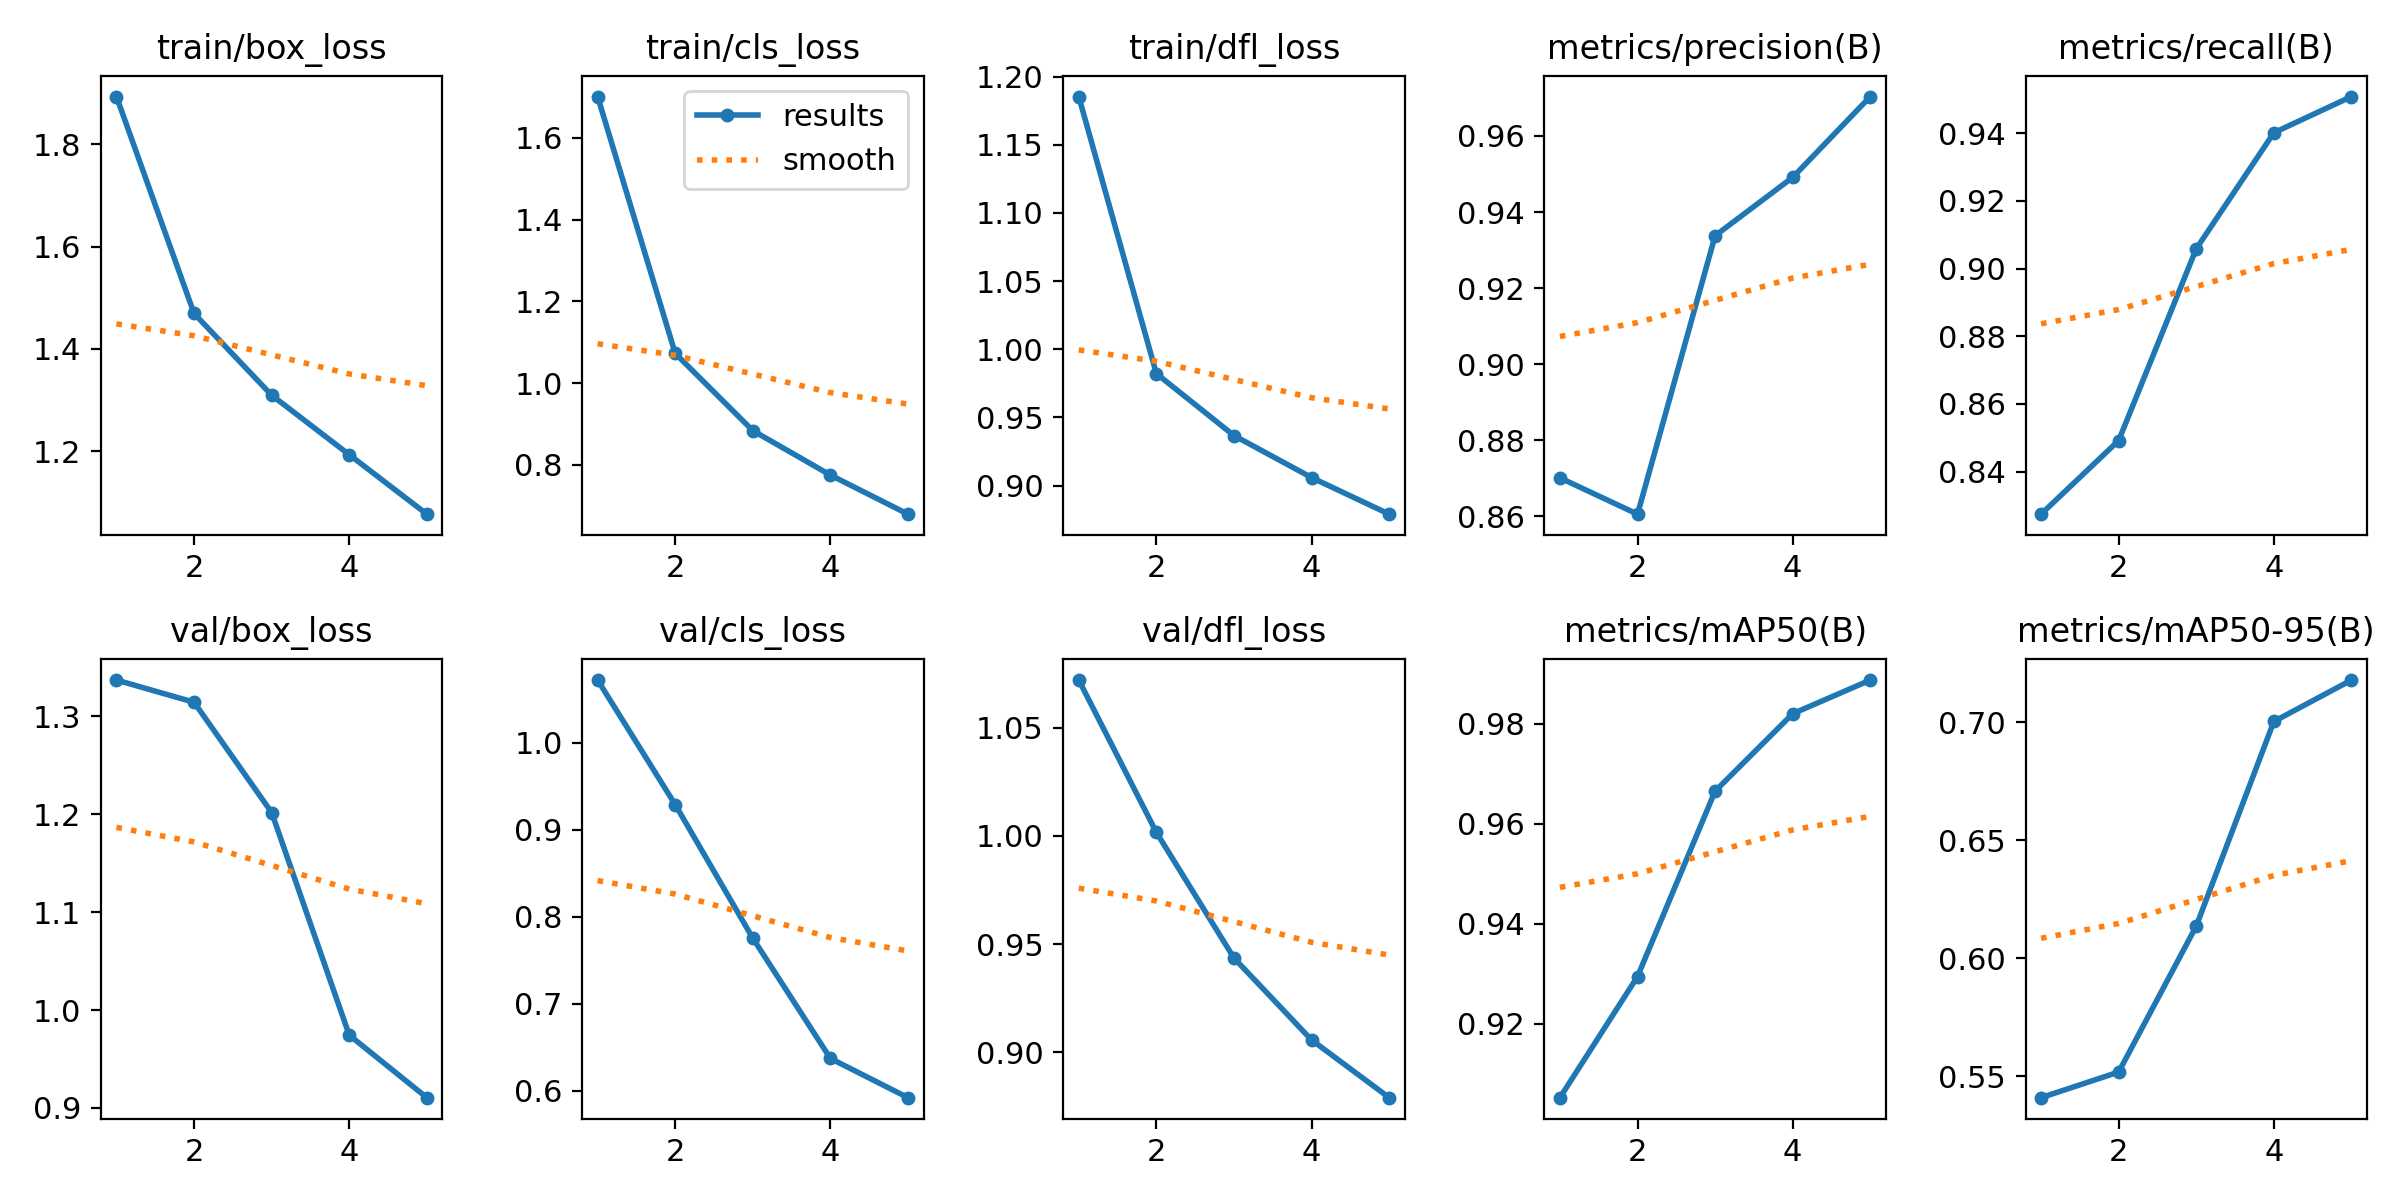

In [28]:
from IPython.display import Image as IPImage
from IPython.display import display

RESULTS_IMAGE = (
    TRAIN_OUTPUT
    / "yolo11n_advertising_board"
    / "results.png"
)

display(
    IPImage(
        filename=str(RESULTS_IMAGE)
    )
)

In [29]:
BEST_WEIGHTS = (
    TRAIN_OUTPUT
    / "yolo11n_advertising_board"
    / "weights"
    / "best.pt"
)

assert BEST_WEIGHTS.exists()

print(
    "Best checkpoint:",
    BEST_WEIGHTS,
)

Best checkpoint: /content/yolo_runs/yolo11n_advertising_board/weights/best.pt


In [30]:
best_model = YOLO(
    str(BEST_WEIGHTS)
)

test_results = best_model.val(

    data=str(DATASET_YAML),

    split="test",

    imgsz=384,

    batch=16,

    device=0,

    workers=2,

    plots=True,

    project=str(TRAIN_OUTPUT),

    name="test_evaluation",

    exist_ok=True,

    verbose=True,
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 129.7±22.8 MB/s, size: 757.5 KB)
val: Scanning /content/yolo_project/yolo/labels/test... 1327 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1327/1327 182.3it/s 7.3s
val: New cache created: /content/yolo_project/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 2.9it/s 28.7s
                   all       1327       2939       0.97      0.957      0.987      0.722
Speed: 0.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/yolo_runs/test_evaluation


In [34]:
box = test_results.box

precision = float(box.mp)
recall = float(box.mr)

if precision + recall > 0:

    f1 = (
        2
        * precision
        * recall
        / (precision + recall)
    )

else:
    f1 = 0.0


yolo_metrics = {

    "model": "YOLO11 Nano",

    "mAP@50:95": float(
        box.map
    ),

    "mAP@50": float(
        box.map50
    ),

    "mAP@75": float(
        box.map75
    ),

    "precision": precision,

    "recall": recall,

    "f1": f1,
}


for metric, value in yolo_metrics.items():

    if isinstance(
        value,
        float,
    ):

        print(
            f"{metric:12s}: "
            f"{value:.4f} "
            f"({value*100:.2f}%)"
        )

    else:

        print(
            f"{metric:12s}: "
            f"{value}"
        )

model       : YOLO11 Nano
mAP@50:95   : 0.7221 (72.21%)
mAP@50      : 0.9866 (98.66%)
mAP@75      : 0.9080 (90.80%)
precision   : 0.9703 (97.03%)
recall      : 0.9575 (95.75%)
f1          : 0.9639 (96.39%)


In [36]:
rf_detr_metrics = {

    "mAP@50:95": 0.8797,

    "mAP@50": 0.9883,

    "mAP@75": 0.9786,

    "precision": 0.9871,

    "recall": 0.9867,

    "f1": 0.9869,
}

In [38]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "RF-DETR Nano": rf_detr_metrics,
        "YOLO11 Nano": {
            key: yolo_metrics[key]
            for key in rf_detr_metrics
        },
    }
)

comparison

,RF-DETR Nano,YOLO11 Nano
mAP@50:95,0.8797,0.722103
mAP@50,0.9883,0.986565
mAP@75,0.9786,0.907982
precision,0.9871,0.970344
recall,0.9867,0.957456
f1,0.9869,0.963857


In [39]:
comparison["Difference YOLO - RF-DETR"] = (
    comparison["YOLO11 Nano"]
    - comparison["RF-DETR Nano"]
)

comparison

,RF-DETR Nano,YOLO11 Nano,Difference YOLO - RF-DETR
mAP@50:95,0.8797,0.722103,-0.157597
mAP@50,0.9883,0.986565,-0.001735
mAP@75,0.9786,0.907982,-0.070618
precision,0.9871,0.970344,-0.016756
recall,0.9867,0.957456,-0.029244
f1,0.9869,0.963857,-0.023043


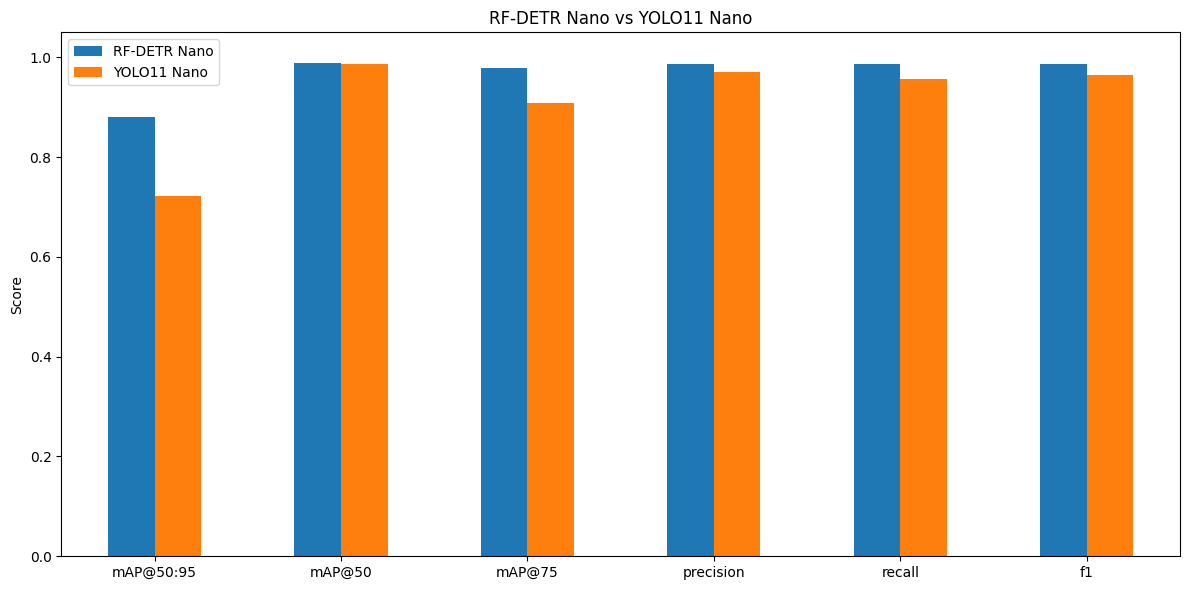

In [40]:
import matplotlib.pyplot as plt

ax = comparison[
    [
        "RF-DETR Nano",
        "YOLO11 Nano",
    ]
].plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    ""
)

ax.set_title(
    "RF-DETR Nano vs YOLO11 Nano"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [41]:
import json

METRICS_FILE = (
    TRAIN_OUTPUT
    / "yolo_test_metrics.json"
)

with METRICS_FILE.open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        yolo_metrics,
        f,
        indent=2,
    )

print(
    "Metriche salvate:",
    METRICS_FILE,
)

Metriche salvate: /content/yolo_runs/yolo_test_metrics.json


In [42]:
COMPARISON_FILE = (
    TRAIN_OUTPUT
    / "rfdetr_vs_yolo.csv"
)

comparison.to_csv(
    COMPARISON_FILE
)

print(
    COMPARISON_FILE
)

/content/yolo_runs/rfdetr_vs_yolo.csv


In [43]:
DRIVE_OUTPUT = Path(
    "/content/drive/MyDrive/DeepLearning/yolo_results"
)

if DRIVE_OUTPUT.exists():
    shutil.rmtree(
        DRIVE_OUTPUT
    )

shutil.copytree(
    TRAIN_OUTPUT
    / "yolo11n_advertising_board",
    DRIVE_OUTPUT
    / "training",
)

shutil.copy2(
    METRICS_FILE,
    DRIVE_OUTPUT
    / "yolo_test_metrics.json",
)

shutil.copy2(
    COMPARISON_FILE,
    DRIVE_OUTPUT
    / "rfdetr_vs_yolo.csv",
)

print(
    "Risultati copiati su Drive:"
)

print(
    DRIVE_OUTPUT
)

Risultati copiati su Drive:
/content/drive/MyDrive/DeepLearning/yolo_results


In [44]:
DRIVE_BEST = (
    DRIVE_OUTPUT
    / "training"
    / "weights"
    / "best.pt"
)

assert DRIVE_BEST.exists()

print(
    "Best checkpoint salvato:"
)

print(
    DRIVE_BEST
)

Best checkpoint salvato:
/content/drive/MyDrive/DeepLearning/yolo_results/training/weights/best.pt
